In [16]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/faizanhaider01/pensions-dataset/uncles_dataset.csv


In [17]:
df = pd.read_csv('/kaggle/input/datasets/faizanhaider01/pensions-dataset/uncles_dataset.csv')

In [18]:
df.sample(5)

,service_years_spend,pension,alive
166,20.7,2407,0
281,16.7,3066,1
38,28.5,9069,0
198,22.1,11735,1
210,8.2,5362,1


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns


/tmp/ipykernel_554/2936640334.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['pension'])
/tmp/ipykernel_554/2936640334.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['service_years_spend'])


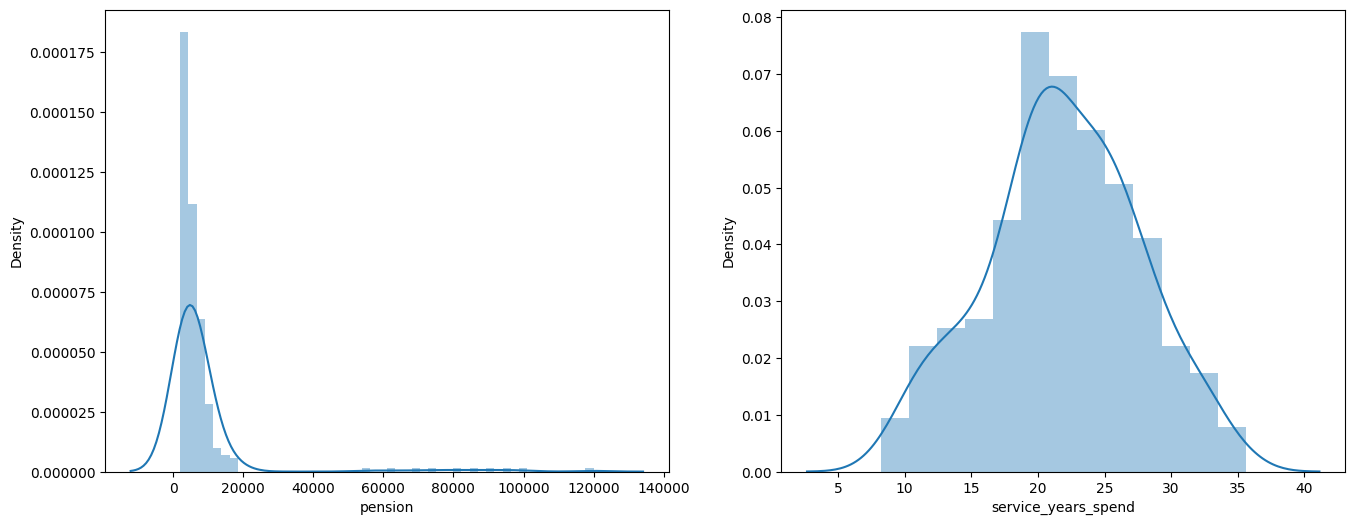

In [20]:
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
sns.distplot(df['pension'])
plt.subplot(1,2,2)
sns.distplot(df['service_years_spend'])
plt.show()

In [21]:
df['pension'].skew()

np.float64(5.26928265282004)

In [22]:
df['pension'].describe()

count       300.000000
mean       8105.653333
std       14718.943492
min        2000.000000
25%        3159.750000
50%        4749.500000
75%        7297.500000
max      120000.000000
Name: pension, dtype: float64

<Axes: xlabel='pension'>

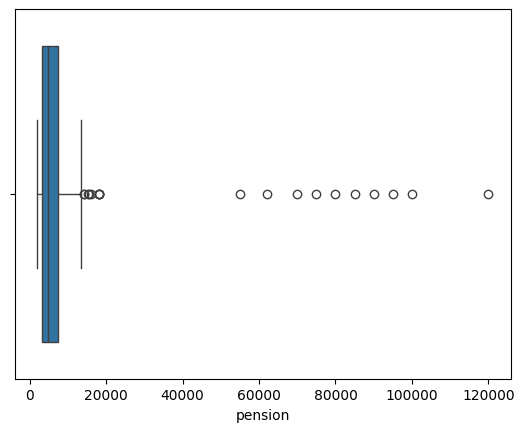

In [23]:
sns.boxplot(x=df['pension'])

In [24]:
percentile_25 =df['pension'].quantile(0.25)
percentile_75 =df['pension'].quantile(0.75)

In [25]:
percentile_75

np.float64(7297.5)

In [26]:
IQR = percentile_75 - percentile_25
IQR

np.float64(4137.75)

In [15]:
Upper_limit = percentile_75 + (1.5*IQR)
Lower_limit = percentile_25 - (1.5*IQR)

In [27]:
Upper_limit

np.float64(13504.125)

In [28]:
Lower_limit

np.float64(-3046.875)

In [29]:
# Finding Outliers Now
df[df['pension']>Upper_limit]


,service_years_spend,pension,alive
6,18.4,120000,1
19,12.7,15385,1
28,30.8,18000,0
29,16.3,75000,1
46,29.7,70000,0
48,19.5,80000,1
62,28.2,85000,1
93,21.8,62000,1
96,33.0,90000,0
107,25.0,55000,0


In [31]:
df[df['pension']<Lower_limit]

,service_years_spend,pension,alive


In [32]:
df[(df['pension']>Upper_limit)|(df['pension']<Lower_limit)]

,service_years_spend,pension,alive
6,18.4,120000,1
19,12.7,15385,1
28,30.8,18000,0
29,16.3,75000,1
46,29.7,70000,0
48,19.5,80000,1
62,28.2,85000,1
93,21.8,62000,1
96,33.0,90000,0
107,25.0,55000,0


# Trimming

In [39]:
new_df = df[df['pension']<Upper_limit]
new_df

,service_years_spend,pension,alive
0,21.0,2397,1
1,15.6,5205,1
2,25.9,8568,0
3,30.8,2070,0
4,20.5,2926,1
...,...,...,...
294,14.0,13258,1
296,25.4,2000,1
297,32.2,5640,0
298,13.8,3494,1


/tmp/ipykernel_554/2404496058.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['pension'])
/tmp/ipykernel_554/2404496058.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['pension'])


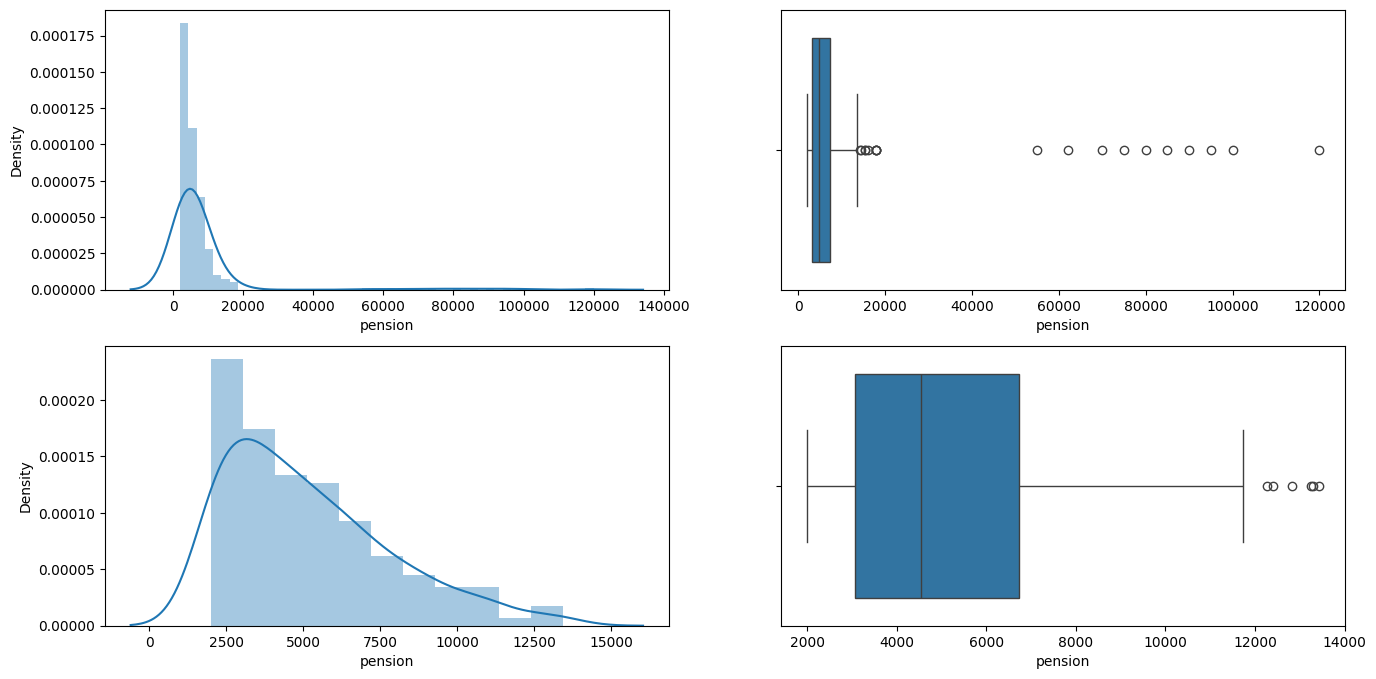

In [40]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['pension'])

plt.subplot(2,2,2)
sns.boxplot(x=df['pension'])

plt.subplot(2,2,3)
sns.distplot(new_df['pension'])

plt.subplot(2,2,4)
sns.boxplot(x=new_df['pension'])

plt.show()

In [45]:
new_df_cap = df.copy()
new_df_cap['pension'] = np.where(new_df_cap['pension']>Upper_limit,Upper_limit,
                     np.where(new_df_cap['pension']<Lower_limit,Lower_limit,new_df_cap['pension']))

In [47]:
new_df_cap.shape

(300, 3)

/tmp/ipykernel_554/2409565254.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['pension'])
/tmp/ipykernel_554/2409565254.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_cap['pension'])


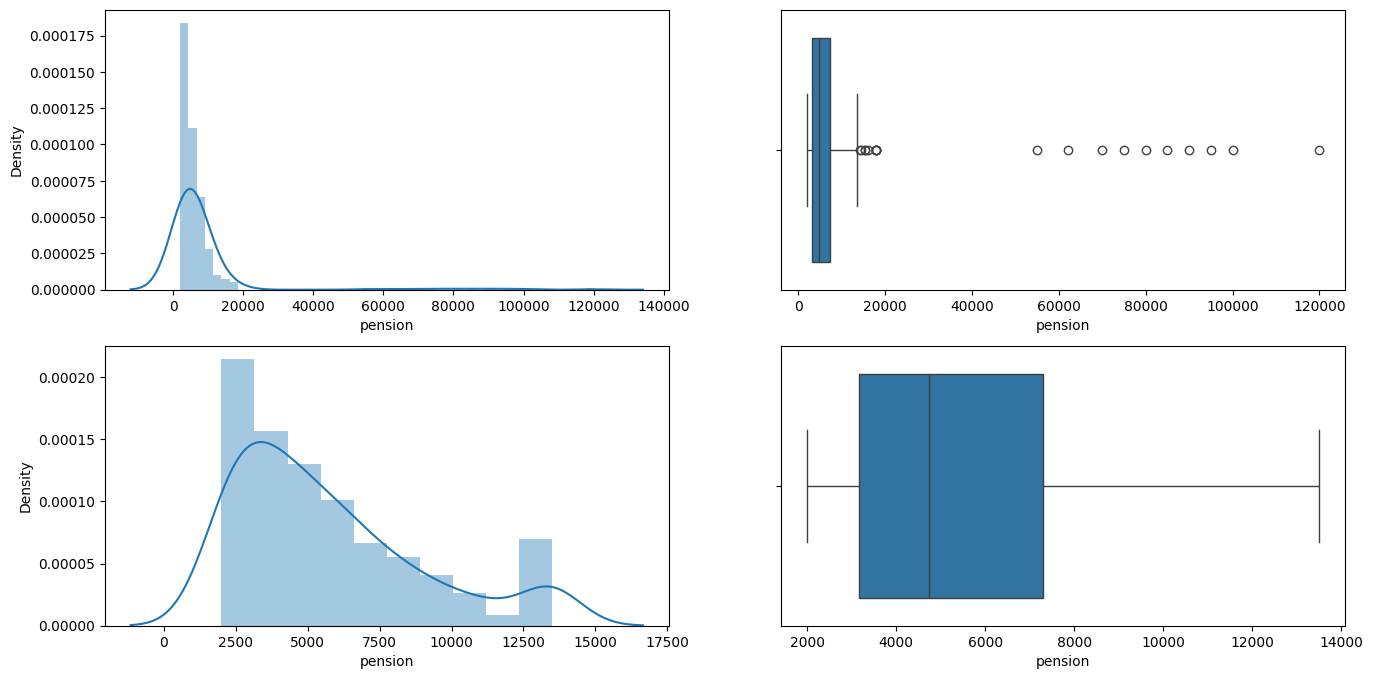

In [48]:

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['pension'])

plt.subplot(2,2,2)
sns.boxplot(x=df['pension'])

plt.subplot(2,2,3)
sns.distplot(new_df_cap['pension'])

plt.subplot(2,2,4)
sns.boxplot(x=new_df_cap['pension'])
plt.show()